---

# Часть 3: Ансамбли на реальных торговых данных

Применим изученные техники к реальной задаче - прогнозированию движения цены акций Google (GOOGL)!

**План занятия:**

1. Загрузка и подготовка данных GOOGL
2. Создание признаков (технические индикаторы)
3. Baseline стратегия на техническом анализе
4. ML модели с защитой от переобучения
5. **Все виды ансамблей**: Voting (hard/soft), Bagging, Stacking
6. **Temporal Bagging** - обучение на разных периодах
7. Оценка с помощью **ROC-AUC**
8. **Умный backtesting** с пороговыми вероятностями

In [ ]:
# Настройка для воспроизводимости
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [ ]:
# Установка необходимых библиотек
!pip install yfinance --quiet
!pip install backtesting --quiet
!pip install optuna --quiet
!pip install catboost --quiet
!pip install xgboost --quiet

# для backtesting необходим даунгрейд библиотеки bokeh
!pip uninstall panel -y --quiet
!pip uninstall bokeh -y --quiet
!pip install bokeh==3.1.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 63.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
holoviews 1.22.0 requires panel>=1.0, which is not installed.


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import yfinance as yf
from datetime import datetime
from tqdm import tqdm

# ML модели
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    BaggingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Метрики
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Backtesting
from backtesting import Strategy, Backtest
from backtesting.lib import crossover

# Optuna
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/usr/local/lib/python3.12/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


## Фиксируем seed для воспроизводимости

In [ ]:
SEED = 777

def seed_everything(seed: int = 42) -> None:
    """Устанавливаем seed для всех библиотек"""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)
print(f"✅ Seed установлен: {SEED}")

✅ Seed установлен: 777


---

## 3.1 Загрузка данных GOOGL

In [ ]:
## Step 1: Download AAPL stock data
#ticker = "AAPL"
#data = yf.download(ticker, start='2023-11-12', end='2025-11-10', interval="1h")

In [ ]:
## Step 1: Download AAPL stock data
#ticker = "GOOGL"
#data = yf.download(ticker, start='2023-11-12', end='2025-11-10', interval="1h")

In [ ]:
# Загрузка данных
data = yf.download('GOOGL', start='2015-01-01', end='2025-11-09')

# Очистка названий колонок
data.columns = data.columns.droplevel(1) if isinstance(data.columns, pd.MultiIndex) else data.columns
data = data[["Open", "High", "Low", "Close", "Volume"]]

print(f"📊 Загружено {len(data)} торговых дней")
print(f"📅 Период: {data.index[0].date()} → {data.index[-1].date()}")
print(f"\n💰 Статистика цены закрытия:")
print(data['Close'].describe())

[*********************100%***********************]  1 of 1 completed

📊 Загружено 2730 торговых дней
📅 Период: 2015-01-02 → 2025-11-07

💰 Статистика цены закрытия:
count    2730.000000
mean       90.976815
std        52.464399
min        24.682762
25%        48.977449
50%        72.045097
75%       131.803680
max       284.750000
Name: Close, dtype: float64


## 3.2 Создание признаков

In [ ]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создает технические индикаторы (без переобучения)
    """
    df = df.copy()

    # === Скользящие средние ===
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()

    # === EMA ===
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

    # === RSI ===
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # === MACD ===
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # === Bollinger Bands ===
    df['BB_Middle'] = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + (2 * bb_std)
    df['BB_Lower'] = df['BB_Middle'] - (2 * bb_std)

    # === Волатильность ===
    df['Volatility_10'] = df['Close'].pct_change().rolling(window=10).std()

    # === Momentum ===
    df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
    df['ROC'] = df['Close'].pct_change(periods=10) * 100

    # === Volume ===
    df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA_20']

    # === Ценовые признаки ===
    df['Daily_Return'] = df['Close'].pct_change()
    df['High_Low_Ratio'] = (df['High'] - df['Low']) / df['Close']

    # === Лаги (только 1 и 2 дня, чтобы избежать переобучения) ===
    df['Close_Lag_1'] = df['Close'].shift(1)
    df['Return_Lag_1'] = df['Daily_Return'].shift(1)

    return df

data = create_features(data)

print(f"✅ Создано признаков")
feature_cols = [col for col in data.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume']]
print(f"📋 Количество признаков: {len(feature_cols)}")

✅ Создано признаков
📋 Количество признаков: 20


In [ ]:
data

Price,Open,High,Low,Close,Volume,SMA_5,SMA_10,SMA_20,EMA_12,EMA_26,...,BB_Lower,Volatility_10,Momentum_5,ROC,Volume_SMA_20,Volume_Ratio,Daily_Return,High_Low_Ratio,Close_Lag_1,Return_Lag_1
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,26.447589,26.606494,26.213205,26.296135,26480000,NaN,NaN,NaN,26.296135,26.296135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014956,NaN,NaN
2015-01-05,26.176955,26.218667,25.710175,25.795088,41182000,NaN,NaN,NaN,26.219051,26.259020,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.019054,0.019713,26.296135,NaN
2015-01-06,25.846736,25.881992,25.104356,25.158484,54456000,NaN,NaN,NaN,26.055887,26.177499,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.024679,0.030909,25.795088,-0.019054
2015-01-07,25.372504,25.399318,25.010005,25.084490,46918000,NaN,NaN,NaN,25.906441,26.096535,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.002941,0.015520,25.158484,-0.024679
2015-01-08,24.903735,25.201183,24.581457,25.171886,73054000,25.501217,NaN,NaN,25.793433,26.028043,...,NaN,NaN,NaN,NaN,NaN,NaN,0.003484,0.024620,25.084490,-0.002941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-03,282.179993,285.529999,279.799988,283.720001,29786000,277.686005,267.285004,257.163501,268.208377,257.835172,...,228.595399,0.018417,14.450012,10.590534,32153805.0,0.926360,0.008997,0.020196,281.190002,-0.001030
2025-11-04,276.750000,281.269989,276.260010,277.540009,30078400,279.700006,269.993004,258.752502,269.644012,259.294790,...,229.332452,0.018022,10.070007,10.812106,32498660.0,0.925527,-0.021782,0.018051,283.720001,0.008997
2025-11-05,278.869995,286.420013,277.339996,284.309998,31010300,281.648004,273.255003,260.737002,271.900318,261.147768,...,230.005551,0.018404,9.739990,12.960386,32983820.0,0.940167,0.024393,0.031937,277.540009,-0.021782


### 📊 Создание таргета

In [ ]:
# Таргет: 1 если завтра цена выше, 0 если ниже
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Удаляем NaN
data = data.dropna()

print(f"📊 Распределение таргета:")
print(data['Target'].value_counts())
print(f"\n📈 Баланс классов: {data['Target'].mean()*100:.1f}% роста, {(1-data['Target'].mean())*100:.1f}% падения")

📊 Распределение таргета:
Target
1    1458
0    1253
Name: count, dtype: int64

📈 Баланс классов: 53.8% роста, 46.2% падения


### 🔪 Разделение на train/test

⚠️ **Важно**: Для временных рядов используем **временное** разделение, а не случайное!

In [ ]:
# Временное разделение
train_data = data[data.index < "2024-01-01"].copy()
test_data = data[data.index >= "2024-01-01"].copy()
#train_data = data[data.index < "2025-06-01"].copy()
#test_data = data[data.index >= "2025-06-01"].copy()
print(f"📊 Train: {len(train_data)} дней ({train_data.index[0].date()} → {train_data.index[-1].date()})")
print(f"📊 Test: {len(test_data)} дней ({test_data.index[0].date()} → {test_data.index[-1].date()})")
# Сохраняем для backtesting# ✅ Сохраняем ВСЕ данные для backtesting (OHLCV + признаки)
bt_test_data = test_data.copy()
# Подготовка признаков
feature_columns = [col for col in data.columns
                   if col not in ['Open', 'High', 'Low', 'Close', 'Volume', 'Target']]
X_train = train_data[feature_columns]
y_train = train_data['Target']
X_test = test_data[feature_columns]
y_test = test_data['Target']
print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

📊 Train: 2245 дней (2015-01-30 → 2023-12-29)
📊 Test: 466 дней (2024-01-02 → 2025-11-07)

✅ X_train shape: (2245, 20)
✅ X_test shape: (466, 20)


---

## 3.3 Baseline: SMA Crossover Strategy

In [ ]:
def SMA(values, n: int) -> float:
    return pd.Series(values).rolling(n).mean()

class SMA_Crossover_Strategy(Strategy):
    n1 = 10
    n2 = 20

    def init(self):
        close = self.data.Close
        self.sma1 = self.I(SMA, close, self.n1)
        self.sma2 = self.I(SMA, close, self.n2)

    def next(self):
        if crossover(self.sma1, self.sma2):
            self.buy()

        elif crossover(self.sma2, self.sma1):
            self.position.close()

bt_baseline = Backtest(bt_test_data, SMA_Crossover_Strategy, cash=10_000, commission=0.002)
baseline_stats = bt_baseline.run()

print("="*80)
print("📊 BASELINE STRATEGY: SMA Crossover")
print("="*80)
print(f"💰 Return: {baseline_stats['Return [%]']:.2f}%")
print(f"📈 Sharpe Ratio: {baseline_stats['Sharpe Ratio']:.3f}")
print(f"📉 Max Drawdown: {baseline_stats['Max. Drawdown [%]']:.2f}%")
print(f"🔢 # Trades: {baseline_stats['# Trades']:.2f}")
print("="*80)

Backtest.run:   0%|          | 0/446 [00:00<?, ?bar/s]

📊 BASELINE STRATEGY: SMA Crossover
💰 Return: 58.61%
📈 Sharpe Ratio: 0.983
📉 Max Drawdown: -26.89%
🔢 # Trades: 10.00


In [ ]:
baseline_stats

,0
Start,2024-01-02 00:00:00
End,2025-11-07 00:00:00
Duration,675 days 00:00:00
Exposure Time [%],59.44206
Equity Final [$],15860.636036
Equity Peak [$],16192.156788
Commissions [$],442.618615
Return [%],58.60636
Buy & Hold Return [%],85.364509
Return (Ann.) [%],28.329906


---

## 3.4 ML Модели

### 🛡️ Стратегия против переобучения:

1. ✅ Используем регуляризацию
2. ✅ Ограничиваем сложность моделей
3. ✅ Используем TimeSeriesSplit (НЕ обычную CV с shuffle!)
4. ✅ Оцениваем по **ROC-AUC** (работает лучше чем accuracy для несбалансированных классов)

In [ ]:
# Словари для хранения результатов
models = {}
predictions = {}

def train_and_evaluate(name: str, model, X_train, y_train, X_test, y_test):
    """
    Обучает модель и выводит метрики с ROC-AUC
    """
    print(f"\n{'='*80}")
    print(f"🤖 {name}")
    print(f"{'='*80}")

    # Обучение
    model.fit(X_train, y_train)

    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    else:
        roc_auc = 0.5

    # Cross-validation score (используем TimeSeriesSplit для временных рядов)
    cv = TimeSeriesSplit(n_splits=3)  # Для временных рядов - НЕ shuffle!
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    print(f"✅ Accuracy:    {accuracy:.4f}")
    print(f"✅ Precision:   {precision:.4f}")
    print(f"✅ Recall:      {recall:.4f}")
    print(f"✅ F1-Score:    {f1:.4f}")
    print(f"⭐ ROC-AUC:     {roc_auc:.4f}")
    print(f"📊 CV ROC-AUC:  {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

    # Проверка на переобучение
    if cv_scores.mean() - roc_auc > 0.1:
        print("⚠️  WARNING: Возможное переобучение (большая разница CV vs Test)")

    # Сохраняем
    models[name] = model
    predictions[name] = {
        'pred': y_pred,
        'proba': y_pred_proba,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_roc_auc': cv_scores.mean()
    }


    return model, y_pred, y_pred_proba

### 1️⃣ Logistic Regression (с регуляризацией)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Pipeline с нормализацией + регуляризация
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=SEED,
        max_iter=1000,
        C=0.1  # сильная регуляризация против переобучения
    ))
])

train_and_evaluate('Logistic Regression', lr_pipeline, X_train, y_train, X_test, y_test)


🤖 Logistic Regression
✅ Accuracy:    0.5558
✅ Precision:   0.6082
✅ Recall:      0.6151
✅ F1-Score:    0.6116
⭐ ROC-AUC:     0.5494
📊 CV ROC-AUC:  0.5071 (±0.0075)


(Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(C=0.1, max_iter=1000, random_state=777))]),
 array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0,

### 2️⃣ Decision Tree (ограниченная глубина)

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=3,  # ограничиваем глубину
    min_samples_split=50,  # увеличиваем min samples
    min_samples_leaf=25,
    random_state=SEED
)

train_and_evaluate('Decision Tree', dt_model, X_train, y_train, X_test, y_test)


🤖 Decision Tree
✅ Accuracy:    0.5386
✅ Precision:   0.6068
✅ Recall:      0.5358
✅ F1-Score:    0.5691
⭐ ROC-AUC:     0.5349
📊 CV ROC-AUC:  0.5028 (±0.0055)


(DecisionTreeClassifier(max_depth=3, min_samples_leaf=25, min_samples_split=50,
                        random_state=777),
 array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1

### 3️⃣ Random Forest (с регуляризацией)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features='sqrt',  # ограничиваем признаки
    random_state=SEED,
    n_jobs=-1
)

train_and_evaluate('Random Forest', rf_model, X_train, y_train, X_test, y_test)


🤖 Random Forest
✅ Accuracy:    0.4506
✅ Precision:   0.6364
✅ Recall:      0.0792
✅ F1-Score:    0.1409
⭐ ROC-AUC:     0.5269
📊 CV ROC-AUC:  0.5096 (±0.0203)


(RandomForestClassifier(max_depth=7, min_samples_leaf=10, min_samples_split=10,
                        n_jobs=-1, random_state=777),
 array([0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### 4️⃣ XGBoost (с регуляризацией)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,  # используем только 80% данных
    colsample_bytree=0.8,  # используем только 80% признаков
    reg_alpha=0.1,  # L1 регуляризация
    reg_lambda=1.0,  # L2 регуляризация
    random_state=SEED,
    eval_metric='logloss'
)

train_and_evaluate('XGBoost', xgb_model, X_train, y_train, X_test, y_test)


🤖 XGBoost
✅ Accuracy:    0.5365
✅ Precision:   0.6070
✅ Recall:      0.5245
✅ F1-Score:    0.5628
⭐ ROC-AUC:     0.5500
📊 CV ROC-AUC:  0.5018 (±0.0209)


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.01, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=50, n_jobs=None,
               num_parallel_tree=None, ...),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 

### 5️⃣ CatBoost (с регуляризацией)

In [ ]:
catboost_model = CatBoostClassifier(
    iterations=100,
    depth=3,
    learning_rate=0.01,
    l2_leaf_reg=3.0,  # L2 регуляризация
    random_seed=SEED,
    verbose=0
)

train_and_evaluate('CatBoost', catboost_model, X_train, y_train, X_test, y_test)


🤖 CatBoost
✅ Accuracy:    0.4700
✅ Precision:   0.6184
✅ Recall:      0.1774
✅ F1-Score:    0.2757
⭐ ROC-AUC:     0.5468
📊 CV ROC-AUC:  0.5039 (±0.0196)


(<catboost.core.CatBoostClassifier at 0x7a100a98cce0>,
 array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
        0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0

---

## 3.5 🎯 Ансамбли: Все варианты

### 1️⃣ Voting Ensemble: Hard vs Soft

In [ ]:
print("\n" + "="*80)
print("🗳️ VOTING ENSEMBLE: Hard vs Soft")
print("="*80)

# Выбираем лучшие базовые модели
base_estimators = [
    ('lr', lr_pipeline),
    ('cb', catboost_model),
    ('xgb', xgb_model)
]

# Hard Voting
voting_hard = VotingClassifier(
    estimators=base_estimators,
    voting='hard'
)

train_and_evaluate('Voting Ensemble (Hard)', voting_hard, X_train, y_train, X_test, y_test)

# Soft Voting
voting_soft = VotingClassifier(
    estimators=base_estimators,
    voting='soft'
)

train_and_evaluate('Voting Ensemble (Soft)', voting_soft, X_train, y_train, X_test, y_test)


🗳️ VOTING ENSEMBLE: Hard vs Soft

🤖 Voting Ensemble (Hard)
✅ Accuracy:    0.5150
✅ Precision:   0.6000
✅ Recall:      0.4415
✅ F1-Score:    0.5087
⭐ ROC-AUC:     0.5000
📊 CV ROC-AUC:  nan (±nan)

🤖 Voting Ensemble (Soft)
✅ Accuracy:    0.5215
✅ Precision:   0.6000
✅ Recall:      0.4755
✅ F1-Score:    0.5305
⭐ ROC-AUC:     0.5552
📊 CV ROC-AUC:  0.5028 (±0.0122)


(VotingClassifier(estimators=[('lr',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('model',
                                                LogisticRegression(C=0.1,
                                                                   max_iter=1000,
                                                                   random_state=777))])),
                              ('cb',
                               <catboost.core.CatBoostClassifier object at 0x7a100a98cce0>),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device...
                                             feature_weights=Non

### 2️⃣ Bagging Ensemble

In [ ]:
print("\n" + "="*80)
print("🎒 BAGGING ENSEMBLE")
print("="*80)

# Bagging с Decision Tree
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=SEED),
    n_estimators=20,
    max_samples=0.8,  # используем 80% данных для каждой модели
    max_features=0.8,  # используем 80% признаков
    random_state=SEED,
    n_jobs=-1
)

train_and_evaluate('Bagging (DecisionTree)', bagging_model, X_train, y_train, X_test, y_test)


🎒 BAGGING ENSEMBLE

🤖 Bagging (DecisionTree)
✅ Accuracy:    0.5107
✅ Precision:   0.6194
✅ Recall:      0.3623
✅ F1-Score:    0.4571
⭐ ROC-AUC:     0.5461
📊 CV ROC-AUC:  0.5000 (±0.0254)


(BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    random_state=777),
                   max_features=0.8, max_samples=0.8, n_estimators=20, n_jobs=-1,
                   random_state=777),
 array([0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
    

In [ ]:
print("Распределение классов в y_train:")
print(pd.Series(y_train).value_counts(normalize=True))

# Базовые модели (level 0)
stacking_estimators = [
    ('lr', lr_pipeline),
    ('dt', dt_model),
    ('cb', catboost_model)
]

from sklearn.metrics import classification_report
for name, model in stacking_estimators:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, pred))

Распределение классов в y_train:
Target
1    0.531403
0    0.468597
Name: proportion, dtype: float64

lr Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.48      0.48       201
           1       0.61      0.62      0.61       265

    accuracy                           0.56       466
   macro avg       0.55      0.55      0.55       466
weighted avg       0.55      0.56      0.56       466


dt Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.54      0.50       201
           1       0.61      0.54      0.57       265

    accuracy                           0.54       466
   macro avg       0.54      0.54      0.54       466
weighted avg       0.55      0.54      0.54       466


cb Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.86      0.58       201
           1       0.62      0.18      0.28       265



### 3️⃣ Stacking Ensemble

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=3) #не работает в пайплайне
meta_X_train, meta_y_train = [], []

for train_idx, val_idx in tscv.split(X_train):
    # Разбиваем данные согласно временному порядку
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


    # Предсказания всех базовых моделей для валидационной части
    fold_preds = []
    for name, model in stacking_estimators:
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict_proba(X_fold_val)[:, 1]  # Вероятность класса 1
        fold_preds.append(preds)

    # Сохраняем матрицу предсказаний и истинные значения для этого фолда
    meta_X_train.append(np.column_stack(fold_preds))
    meta_y_train.append(y_fold_val.values)


# Объединяем фолды
meta_X_train = np.vstack(meta_X_train)
meta_y_train = np.concatenate(meta_y_train)

# Предсказания на тестовой выборке
meta_X_test = np.column_stack([
    model.predict_proba(X_test)[:, 1] for name, model in stacking_estimators
])

# Обучаем финальную модель
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1
)
final_model.fit(meta_X_train, meta_y_train)


# Вызываем train_and_evaluate
train_and_evaluate(
    name='Stacking Ensemble',
    model=final_model,
    X_train=meta_X_train,
    y_train=meta_y_train,
    X_test=meta_X_test,
    y_test=y_test
)


🤖 Stacking Ensemble
✅ Accuracy:    0.5300
✅ Precision:   0.5827
✅ Recall:      0.6113
✅ F1-Score:    0.5967
⭐ ROC-AUC:     0.5141
📊 CV ROC-AUC:  0.5284 (±0.0090)


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=2, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=50, n_jobs=None,
               num_parallel_tree=None, ...),
 array([1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 

---

## 3.6 🎯 Temporal Bagging
Обучим модели на разных временных периодах с правильной обработкой.

In [ ]:
train_data

Price,Open,High,Low,Close,Volume,SMA_5,SMA_10,SMA_20,EMA_12,EMA_26,...,Volatility_10,Momentum_5,ROC,Volume_SMA_20,Volume_Ratio,Daily_Return,High_Low_Ratio,Close_Lag_1,Return_Lag_1,Target
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,25.772249,26.968995,25.731529,26.693396,121108000,26.031658,26.026295,25.619277,25.932235,25.880337,...,0.022920,-0.218491,6.654642,52846300.0,2.291703,0.047386,0.046358,25.485723,0.001561,0
2015-02-02,26.532998,26.641252,25.907314,26.427725,75378000,25.986767,26.134250,25.625856,26.008464,25.920885,...,0.023371,-0.224453,4.258901,55291200.0,1.363291,-0.009953,0.027772,26.693396,0.047386,1
2015-02-03,26.315499,26.688427,26.160071,26.482349,47062000,26.107038,26.250250,25.660219,26.081369,25.962475,...,0.023312,0.601353,4.580941,55585200.0,0.846664,0.002067,0.019951,26.427725,-0.009953,0
2015-02-04,26.474401,26.653665,26.071678,26.124813,33896000,26.242801,26.278604,25.708536,26.088053,25.974500,...,0.023237,0.678818,1.097240,54557200.0,0.621293,-0.013501,0.022277,26.482349,0.002067,1
2015-02-05,26.215685,26.352740,26.101970,26.310036,33176000,26.407664,26.241510,25.769813,26.122204,25.999354,...,0.020701,0.824312,-1.390290,53870100.0,0.615852,0.007090,0.009531,26.124813,-0.013501,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,139.805759,141.017403,139.746172,140.520828,26532200,137.591019,134.633423,133.618919,135.493067,134.052717,...,0.010909,8.829102,4.815194,32696500.0,0.811469,0.007620,0.009047,139.458130,0.015035,1
2023-12-26,140.620126,141.702656,140.222872,140.550613,16780300,138.727182,135.450786,133.872669,136.271151,134.534043,...,0.009274,5.680817,6.174510,32363690.0,0.518492,0.000212,0.010528,140.520828,0.007620,0
2023-12-27,140.620122,141.106771,138.931770,139.408478,19628600,139.466086,136.230408,134.030083,136.753817,134.895112,...,0.009630,3.694519,5.923627,32408620.0,0.605660,-0.008126,0.015602,140.550613,0.000212,0


In [ ]:
print("\n" + "="*80)
print("⏰ TEMPORAL BAGGING: Обучение на разных периодах")
print("="*80)

# Определяем периоды
#time_periods = [
#    ("2023-12-01", "2024-03-01"),
#    ("2024-03-01", "2024-06-01"),
#    ("2024-06-01", "2024-09-01"),
#    ("2024-09-01", "2024-12-01"),
#    ("2024-12-01", "2025-03-01"),
#    ("2025-03-01", "2025-06-01"),
#]

time_periods = [
    ("2015-01-01", "2016-01-01"),
    ("2016-01-01", "2017-01-01"),
    ("2017-01-01", "2018-01-01"),
    ("2018-01-01", "2019-01-01"),
    ("2019-01-01", "2020-01-01"),
    ("2020-01-01", "2021-01-01"),
    ("2021-01-01", "2022-01-01"),
    ("2022-01-01", "2023-01-01"),
    ("2023-01-01", "2024-01-01"),
]

temporal_models = []

print("\n🔄 Обучение моделей на каждом периоде...\n")

for start, end in tqdm(time_periods, desc="Training"):
    period_data = train_data[(train_data.index >= start) & (train_data.index < end)]

    # Проверяем, что данных достаточно
    if len(period_data) < 100:
        print(f"⚠️  Пропускаем период {start}-{end}: недостаточно данных")
        continue

    X_period = period_data[feature_columns]
    y_period = period_data['Target']

    # Проверяем баланс классов
    if y_period.nunique() < 2:
        print(f"⚠️  Пропускаем период {start}-{end}: только один класс")
        continue

    # Используем простую, устойчивую модель
    model = RandomForestClassifier(
        n_estimators=30,
        max_depth=4,
        min_samples_split=20,
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(X_period, y_period)
    temporal_models.append(model)

print(f"\n✅ Обучено {len(temporal_models)} моделей")


⏰ TEMPORAL BAGGING: Обучение на разных периодах

🔄 Обучение моделей на каждом периоде...



Training: 100%|██████████| 9/9 [00:01<00:00,  8.67it/s]


✅ Обучено 9 моделей


In [80]:
# Получаем предсказания
if len(temporal_models) > 0:
    all_probas = []
    for model in temporal_models:
        proba = model.predict_proba(X_test)[:, 1]
        all_probas.append(proba)

    # Усредняем вероятности
    avg_proba = np.mean(all_probas, axis=0)
    temporal_pred = (avg_proba >= 0.5).astype(int)

    # Метрики
    temporal_accuracy = accuracy_score(y_test, temporal_pred)
    temporal_roc_auc = roc_auc_score(y_test, avg_proba)

    print("\n" + "="*80)
    print("⏰ TEMPORAL BAGGING RESULTS")
    print("="*80)
    print(f"✅ Accuracy:  {temporal_accuracy:.4f}")
    print(f"⭐ ROC-AUC:   {temporal_roc_auc:.4f}")

    # Анализ согласованности
    proba_std = np.std(all_probas, axis=0)
    print(f"📊 Средний разброс: {proba_std.mean():.3f}")
    print("="*80)

    # Сохраняем
    predictions['Temporal Bagging'] = {
        'pred': temporal_pred,
        'proba': np.column_stack([1-avg_proba, avg_proba]),
        'accuracy': temporal_accuracy,
        'roc_auc': temporal_roc_auc,
        'cv_roc_auc': temporal_roc_auc
    }
else:
    print("⚠️  Temporal Bagging не удалось обучить")


⏰ TEMPORAL BAGGING RESULTS
✅ Accuracy:  0.4313
⭐ ROC-AUC:   0.4881
📊 Средний разброс: 0.073


Хуже случайной модели

---

## 3.7 📊 Итоговое сравнение по ROC-AUC

In [ ]:
# Создаем таблицу сравнения
comparison_df = pd.DataFrame({
    'Model': list(predictions.keys()),
    'Accuracy': [predictions[m]['accuracy'] for m in predictions.keys()],
    'ROC-AUC': [predictions[m]['roc_auc'] for m in predictions.keys()],
    'CV ROC-AUC': [predictions[m]['cv_roc_auc'] for m in predictions.keys()]
}).sort_values('ROC-AUC', ascending=False)

# Добавляем индикатор переобучения
comparison_df['Overfitting'] = (comparison_df['CV ROC-AUC'] - comparison_df['ROC-AUC']) > 0.05

print("\n" + "="*80)
print("🏆 ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (отсортировано по ROC-AUC)")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

print("\n💡 Интерпретация:")
print("   • ROC-AUC > 0.55 - модель работает лучше случайного угадывания")
print("   • ROC-AUC ≈ 0.50 - модель работает как случайное угадывание")
print("   • Overfitting = True - модель переобучилась (большая разница CV vs Test)")


🏆 ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (отсортировано по ROC-AUC)
                 Model  Accuracy  ROC-AUC  CV ROC-AUC  Overfitting
Voting Ensemble (Soft)  0.521459 0.555168    0.502832        False
               XGBoost  0.536481 0.550042    0.501825        False
   Logistic Regression  0.555794 0.549404    0.507114        False
              CatBoost  0.469957 0.546757    0.503863        False
Bagging (DecisionTree)  0.510730 0.546072    0.499972        False
         Decision Tree  0.538627 0.534948    0.502788        False
         Random Forest  0.450644 0.526931    0.509565        False
     Stacking Ensemble  0.530043 0.514127    0.528395        False
Voting Ensemble (Hard)  0.515021 0.500000         NaN        False
      Temporal Bagging  0.431330 0.488107    0.488107        False

💡 Интерпретация:
   • ROC-AUC > 0.55 - модель работает лучше случайного угадывания
   • ROC-AUC ≈ 0.50 - модель работает как случайное угадывание
   • Overfitting = True - модель переобучилась (больша

In [ ]:
comparison_df

,Model,Accuracy,ROC-AUC,CV ROC-AUC,Overfitting
6,Voting Ensemble (Soft),0.521459,0.555168,0.502832,False
3,XGBoost,0.536481,0.550042,0.501825,False
0,Logistic Regression,0.555794,0.549404,0.507114,False
4,CatBoost,0.469957,0.546757,0.503863,False
7,Bagging (DecisionTree),0.510730,0.546072,0.499972,False
1,Decision Tree,0.538627,0.534948,0.502788,False
2,Random Forest,0.450644,0.526931,0.509565,False
8,Stacking Ensemble,0.530043,0.514127,0.528395,False
5,Voting Ensemble (Hard),0.515021,0.500000,NaN,False
9,Temporal Bagging,0.431330,0.488107,0.488107,False


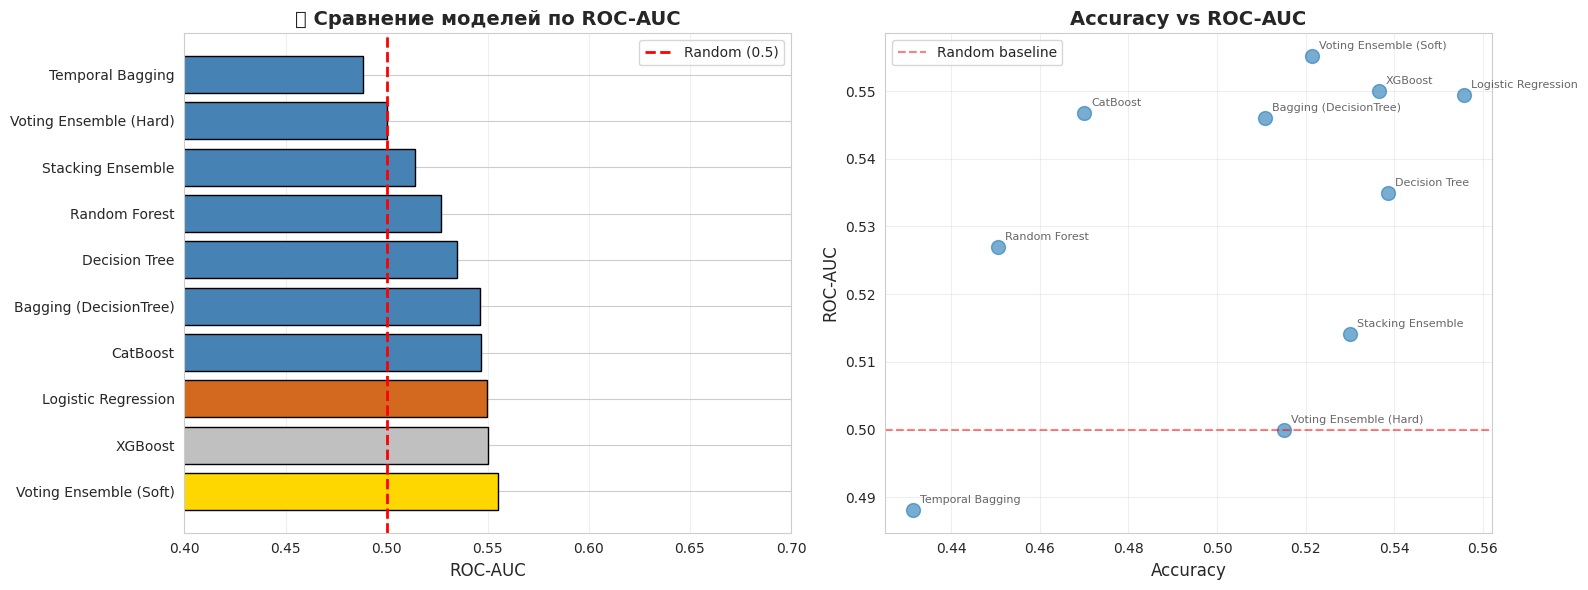


🥇 Лучшая модель по ROC-AUC: Voting Ensemble (Soft)
⭐ ROC-AUC: 0.5552


In [ ]:
# Визуализация ROC-AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC график
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'chocolate' if i == 2 else 'steelblue'
          for i in range(len(comparison_df))]
ax1.barh(comparison_df['Model'], comparison_df['ROC-AUC'], color=colors, edgecolor='black')
ax1.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Random (0.5)')
ax1.set_xlabel('ROC-AUC', fontsize=12)
ax1.set_title('🏆 Сравнение моделей по ROC-AUC', fontsize=14, fontweight='bold')
ax1.set_xlim(0.4, 0.7)
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Accuracy vs ROC-AUC
ax2.scatter(comparison_df['Accuracy'], comparison_df['ROC-AUC'], s=100, alpha=0.6)
for idx, row in comparison_df.iterrows():
    ax2.annotate(row['Model'], (row['Accuracy'], row['ROC-AUC']),
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax2.set_xlabel('Accuracy', fontsize=12)
ax2.set_ylabel('ROC-AUC', fontsize=12)
ax2.set_title('Accuracy vs ROC-AUC', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🥇 Лучшая модель по ROC-AUC: {comparison_df.iloc[0]['Model']}")
print(f"⭐ ROC-AUC: {comparison_df.iloc[0]['ROC-AUC']:.4f}")

---

## 3.8 💰 Умный Backtesting с пороговыми вероятностями

### 🎯 Стратегия:
- **Покупаем** когда вероятность роста > `threshold_buy` (например, 0.60)
- **Продаем** когда вероятность роста < `threshold_sell` (например, 0.40)
- В остальных случаях **держим** позицию

In [ ]:
class Smart_ML_Strategy(Strategy):
    """
    Умная ML стратегия с пороговыми вероятностями
    """
    model = None
    threshold_buy = 0.60
    threshold_sell = 0.40
    feature_columns = None  # Список признаков (устанавливается извне)

    def init(self):
        # ✅ ПРАВИЛЬНО: Извлекаем признаки из self.data (bt_test_data)
        features_data = pd.DataFrame({
            col: self.data.df[col].values
            for col in self.feature_columns
        }, index=self.data.df.index)

        # Получаем вероятности от модели
        if hasattr(self.model, 'predict_proba'):
            proba = self.model.predict_proba(features_data)
            self.predictions_proba = proba[:, 1]  # Вероятность класса 1 (рост)
        else:
            self.predictions_proba = self.model.predict(features_data)

    def next(self):
        current_idx = len(self.data) - 1

        if current_idx >= len(self.predictions_proba):
            return

        signal = self.predictions_proba[current_idx]

        # Умная торговая логика
        if signal > self.threshold_buy:
            # Высокая уверенность в росте - покупаем
            if not self.position:
                self.buy()

        elif signal < self.threshold_sell:
            # Высокая уверенность в падении - продаем
            if self.position:
                self.position.close()


# ✅ Устанавливаем feature_columns перед использованием стратегии
Smart_ML_Strategy.feature_columns = feature_columns

print("✅ Smart ML Strategy создана")
print(f"   • Признаков для предсказания: {len(feature_columns)}")
print(f"   • Пороги: Buy={Smart_ML_Strategy.threshold_buy}, Sell={Smart_ML_Strategy.threshold_sell}")

✅ Smart ML Strategy создана
   • Признаков для предсказания: 20
   • Пороги: Buy=0.6, Sell=0.4


### 🔄 Backtesting для моделей

In [ ]:
backtest_results = {}

def run_smart_backtest(model_name: str, model, threshold_buy=0.60, threshold_sell=0.40):
    """
    Запускает умный backtesting с порогами
    """
    print(f"\n{'='*80}")
    print(f"💰 Backtesting: {model_name}")
    print(f"   📊 Threshold Buy: {threshold_buy}, Threshold Sell: {threshold_sell}")
    print(f"{'='*80}")

    Smart_ML_Strategy.model = model
    Smart_ML_Strategy.threshold_buy = threshold_buy
    Smart_ML_Strategy.threshold_sell = threshold_sell

    bt = Backtest(bt_test_data, Smart_ML_Strategy, cash=10_000, commission=0.002)
    stats = bt.run()

    backtest_results[model_name] = {
        'Return [%]': stats['Return [%]'],
        'Sharpe Ratio': stats['Sharpe Ratio'],
        'Max. Drawdown [%]': stats['Max. Drawdown [%]'],
        '# Trades': stats['# Trades'],
        'Win Rate [%]': stats['Win Rate [%]'] if stats['# Trades'] > 0 else 0
    }

    print(f"💰 Return:        {stats['Return [%]']:.2f}%")
    print(f"📈 Sharpe Ratio:  {stats['Sharpe Ratio']:.3f}")
    print(f"📉 Max Drawdown:  {stats['Max. Drawdown [%]']:.2f}%")
    print(f"🔢 # Trades:      {stats['# Trades']}")
    if stats['# Trades'] > 0:
        print(f"🎯 Win Rate:      {stats['Win Rate [%]']:.1f}%")

    return bt, stats

In [79]:
# ============================================================================
# Оптимизация порогов для КАЖДОЙ модели (кроме стэкинга)
# ============================================================================

print("="*80)
print("🎯 ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ КАЖДОЙ МОДЕЛИ")
print("="*80)
print()

# Параметры оптимизации
MIN_TRADES = 3  # Минимальное количество сделок для включения в результаты

# Диапазоны порогов для тестирования (баланс скорости и точности)
THRESHOLD_RANGE_BUY = [0.55, 0.58, 0.60, 0.63, 0.65]
THRESHOLD_RANGE_SELL = [0.35, 0.38, 0.40, 0.42, 0.45]

print(f"📊 Параметры оптимизации:")
print(f"   MIN_TRADES: {MIN_TRADES}")
print(f"   Пороги покупки: {THRESHOLD_RANGE_BUY}")
print(f"   Пороги продажи: {THRESHOLD_RANGE_SELL}")
print(f"   Комбинаций на модель: {len(THRESHOLD_RANGE_BUY) * len(THRESHOLD_RANGE_SELL)}")
print()

def optimize_thresholds_for_model(model_name, model, min_trades=MIN_TRADES):
    """
    Оптимизация порогов для конкретной модели

    Возвращает:
        best_config: dict с лучшей конфигурацией (или None)
        df_filtered: DataFrame с отфильтрованными результатами
    """
    print(f"{'='*80}")
    print(f"🔬 ОПТИМИЗАЦИЯ: {model_name}")
    print(f"{'='*80}")

    results = []

    # Тестируем все комбинации порогов
    for t_buy in THRESHOLD_RANGE_BUY:
        for t_sell in THRESHOLD_RANGE_SELL:
            if t_buy <= t_sell:  # Пропускаем бессмысленные комбинации
                continue

            Smart_ML_Strategy.model = model
            Smart_ML_Strategy.threshold_buy = t_buy
            Smart_ML_Strategy.threshold_sell = t_sell


            bt = Backtest(bt_test_data, Smart_ML_Strategy,
                         cash=10_000, commission=0.002)
            stats = bt.run()

            results.append({
                'Buy': t_buy,
                'Sell': t_sell,
                'Return [%]': stats['Return [%]'],
                'Sharpe Ratio': stats['Sharpe Ratio'],
                '# Trades': stats['# Trades'],
                'Win Rate [%]': stats['Win Rate [%]'],
                'Max. Drawdown [%]': stats['Max. Drawdown [%]']
            })

    df = pd.DataFrame(results)
    print(f"   Протестировано комбинаций: {len(df)}")

    # Фильтруем по минимальному количеству сделок
    df_filtered = df[df['# Trades'] >= min_trades].copy()

    if len(df_filtered) == 0:
        print(f"   ⚠️ НЕТ конфигураций с >= {min_trades} сделками!")
        best_any = df.loc[df['Return [%]'].idxmax()]
        print(f"   Лучший результат без фильтра: {best_any['Return [%]']:.1f}% "
              f"({int(best_any['# Trades'])} {'сделка' if best_any['# Trades'] == 1 else 'сделки'})")
        print()
        return None, df

    # Сортируем по доходности
    df_filtered = df_filtered.sort_values('Return [%]', ascending=False)

    # Берем лучшую конфигурацию
    best = df_filtered.iloc[0]

    print(f"   ✅ Прошли фильтр: {len(df_filtered)} конфигураций")
    print(f"   🥇 ЛУЧШАЯ КОНФИГУРАЦИЯ:")
    print(f"      Пороги: ({best['Buy']:.2f}, {best['Sell']:.2f})")
    print(f"      Return: {best['Return [%]']:+.2f}%")
    print(f"      Trades: {int(best['# Trades'])}")
    print(f"      Sharpe: {best['Sharpe Ratio']:.2f}")
    print(f"      Win Rate: {best['Win Rate [%]']:.1f}%")
    print()

    best_config = {
        'model_name': model_name,
        'model': model,
        'threshold_buy': best['Buy'],
        'threshold_sell': best['Sell'],
        'return': best['Return [%]'],
        'sharpe': best['Sharpe Ratio'],
        'trades': int(best['# Trades']),
        'win_rate': best['Win Rate [%]'],
        'max_drawdown': best['Max. Drawdown [%]']
    }

    return best_config, df_filtered


# Применяем оптимизацию ко всем топ-моделям
n_top = min(10, len(comparison_df))
top_models = comparison_df.head(n_top)

optimized_configs = {}
optimization_details = {}
failed_models = []

print(f"🎯 Начинаем оптимизацию для {len(top_models)} моделей...\n")

# Модели, которые требуют специальной обработки
EXCLUDED_MODELS = ['Stacking Ensemble']

for idx, row in top_models.iterrows():
    model_name = row['Model']

    # ✅ Пропускаем Stacking
    if model_name in EXCLUDED_MODELS:
        print(f"ℹ️ {model_name} пропущена (требует специальной обработки)")
        print(f"   Причина: Stacking работает на предсказаниях базовых моделей,")
        print(f"   а не на исходных признаках\n")
        continue

    if model_name not in models:
        print(f"⚠️ Модель {model_name} не найдена в словаре models\n")
        failed_models.append(model_name)
        continue

    # Оптимизируем пороги для этой модели
    best_config, all_results = optimize_thresholds_for_model(
        model_name,
        models[model_name],
        min_trades=MIN_TRADES
    )

    if best_config is not None:
        optimized_configs[model_name] = best_config
        optimization_details[model_name] = all_results
    else:
        failed_models.append(model_name)

print("="*80)
print(f"✅ ЗАВЕРШЕНО")
print(f"   Успешно оптимизировано: {len(optimized_configs)} моделей")
if failed_models:
    print(f"   ⚠️ Не прошли фильтр: {len(failed_models)} моделей")
    for m in failed_models:
        print(f"      • {m}")
print("="*80)

🎯 ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ КАЖДОЙ МОДЕЛИ

📊 Параметры оптимизации:
   MIN_TRADES: 3
   Пороги покупки: [0.55, 0.58, 0.6, 0.63, 0.65]
   Пороги продажи: [0.35, 0.38, 0.4, 0.42, 0.45]
   Комбинаций на модель: 25

🎯 Начинаем оптимизацию для 10 моделей...

🔬 ОПТИМИЗАЦИЯ: Voting Ensemble (Soft)


Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]

   Протестировано комбинаций: 25
   ✅ Прошли фильтр: 25 конфигураций
   🥇 ЛУЧШАЯ КОНФИГУРАЦИЯ:
      Пороги: (0.55, 0.35)
      Return: +52.23%
      Trades: 60
      Sharpe: 1.08
      Win Rate: 70.0%

⚠️ Модель Temporal Bagging не найдена в словаре models

✅ ЗАВЕРШЕНО
   Успешно оптимизировано: 4 моделей
   ⚠️ Не прошли фильтр: 5 моделей
      • XGBoost
      • CatBoost
      • Decision Tree
      • Random Forest
      • Temporal Bagging


Можно посмотреть разбиение, максимизирующее Sharp ratio (сейчас у всех моделей низкий), наибольший Sharp ratio дал Bagging

In [ ]:
bt_data['stacking_proba']

,stacking_proba
Date,
2024-01-02,0.527433
2024-01-03,0.480899
2024-01-04,0.443298
2024-01-05,0.488593
2024-01-08,0.380387
...,...
2025-11-03,0.466423
2025-11-04,0.543458
2025-11-05,0.466423


In [ ]:
print("\n" + "="*80)
print("🎯 БЭКТЕСТ СТЕКИНГА БЕЗ ОПТИМИЗАЦИИ ПОРОГОВ")
print("="*80)


# Фиксированные пороги (можно поменять на свои)
FIXED_BUY_THRESHOLD = 0.6
FIXED_SELL_THRESHOLD = 0.4

# Предсказания финальной модели на тестовых данных
stacking_proba = final_model.predict_proba(meta_X_test)[:, 1] #final_model = XGBClassifier

# Подготавливаем данные для бэктестинга
bt_data = bt_test_data.copy()
bt_data['stacking_proba'] = stacking_proba

# Определяем стратегию с фиксированными порогами
class StackingStrategy(Strategy):
    def init(self):
        self.proba = self.data.stacking_proba  # берём вероятности из данных
        self.buy_threshold = 0.60            # порог для покупки
        self.sell_threshold = 0.40          # порог для продажи


    def next(self):
        if self.proba > self.buy_threshold:
            self.buy()  # открываем/держим позицию
        elif self.proba < self.sell_threshold:
            self.sell()  # закрываем позицию

# Запуск бэктеста
bt = Backtest(bt_data, StackingStrategy, cash=10_000, commission=0.002)
stats = bt.run()

# Формируем результат в том же формате, что и optimize_thresholds_for_model
stacking_result = {
    'model_name': 'Stacking Ensemble (Fixed Thresholds)',
    'threshold_buy': FIXED_BUY_THRESHOLD,
    'threshold_sell': FIXED_SELL_THRESHOLD,
    'return': round(stats['Return [%]'], 2),
    'sharpe': round(stats['Sharpe Ratio'], 2),
    'trades': int(stats['# Trades']),
    'win_rate': round(stats['Win Rate [%]'], 1),
    'max_drawdown': round(stats['Max. Drawdown [%]'], 1)
}

# Выводим результат
print(f"\n📊 РЕЗУЛЬТАТ ДЛЯ СТЕКИНГА (пороги: {FIXED_BUY_THRESHOLD:.2f} / {FIXED_SELL_THRESHOLD:.2f}):")
print(f"   Return: {stacking_result['return']:+.2f}%")
print(f"   Sharpe: {stacking_result['sharpe']:.2f}")
print(f"   # Trades: {stacking_result['trades']}")
print(f"   Win Rate: {stacking_result['win_rate']:.1f}%")
print(f"   Max Drawdown: {stacking_result['max_drawdown']:.1f}%")

# Добавляем в общие результаты (если нужно сравнивать с оптимизированными моделями)
optimized_configs['Stacking Ensemble (Fixed)'] = stacking_result


print("\n" + "-"*80)



🎯 БЭКТЕСТ СТЕКИНГА БЕЗ ОПТИМИЗАЦИИ ПОРОГОВ


Backtest.run:   0%|          | 0/465 [00:00<?, ?bar/s]


📊 РЕЗУЛЬТАТ ДЛЯ СТЕКИНГА (пороги: 0.60 / 0.40):
   Return: +0.00%
   Sharpe: nan
   # Trades: 0
   Win Rate: nan%
   Max Drawdown: -0.0%

--------------------------------------------------------------------------------


---

## 📝 Итоговые выводы

### Что мы узнали:

1. **Переобучение - проблема**
   - Модели с высокой сложностью легко переобучаются на малых данных
   - Регуляризация важна
   - **TimeSeriesSplit** (НЕ обычная CV!) используем для временных рядов

2. **ROC-AUC для оценки модели**
   - ROC-AUC показывает способность модели разделять классы

3. **Ансамбли помогают**
Посмотрели на примерах
   - Voting (hard/soft)
   - Bagging
   - Stacking
   - Temporal Bagging

4. **Умный backtesting важен**
   - Пороговые вероятности позволяют торговать только при высокой уверенности
   - Оптимизация порогов улучшает результаты
   - Меньше сделок ≠ хуже результат

### Ключевые метрики:

- ✅ **ROC-AUC > 0.55** - модель работает лучше случайности (в нашем случае не удалось подобрать хорошую модель)
- ✅ **Sharpe Ratio > 1.0** - хорошее соотношение риск/доходность
- ✅ **Win Rate > 50%** - больше прибыльных сделок

### Что можно посмотреть/улучшить:

1. Рассмотреть другие признаки
2. Использовать Optuna для подбора гиперпараметров моделей
3. Добавить stop-loss и take-profit
4. Посмотреть как ведут себя модели/стратегии на других акциях